In [2]:
!pip install -q pandas numpy

In [3]:

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split

In [19]:
# Thay 'vimunch-vi-metaphor-raw' bằng tên dataset raw của bạn trên Kaggle
DATA_DIR = "/kaggle/input/vimunch"
JSON_FILE = "ViMUNCH.json"

data_path = os.path.join(DATA_DIR, JSON_FILE)
print("Data path:", data_path)
print("Exists?", os.path.exists(data_path))

with open(data_path, "r", encoding="utf-8") as f:
    raw = json.load(f)

print("Số mẫu:", len(raw))
print("Keys trong 1 mẫu:", raw[0].keys())

df = pd.DataFrame(raw)
df = df.reset_index().rename(columns={"index": "id"})
df.head()

Data path: /kaggle/input/vimunch/ViMUNCH.json
Exists? True
Số mẫu: 8501
Keys trong 1 mẫu: dict_keys(['sentence', 'have_metaphor', 'interpretation', 'metaphor_types', 'metaphor_phrases', 'notes', 'scores'])


,id,sentence,have_metaphor,interpretation,metaphor_types,metaphor_phrases,notes,scores
0,0,Trong ngôn ngữ thiên nhiên Lễ vật là nụ cười,1,"Trong ngôn ngữ của sự chân thành và thiện chí,...","[emotional, ontological]","[{'phrase': 'Lễ vật', 'start': 27, 'end': 33, ...",,"{'accuracy': 4, 'clarity': 4, 'naturalness': 4..."
1,1,Non nước hẹn hò sóng mây dạm ngõ,1,Cảnh non nước như đang trò chuyện và gặp gỡ nh...,"[emotional, ontological]","[{'phrase': 'Non nước hẹn hò', 'start': 0, 'en...",,"{'accuracy': 4, 'clarity': 4, 'naturalness': 4..."
2,2,Chim trời phong lưu chim trời Còng gió hào hoa...,1,"Những người tự do, phong lưu như chim trời, và...","[emotional, ontological]","[{'phrase': 'Chim trời phong lưu', 'start': 0,...",,"{'accuracy': 3, 'clarity': 3, 'naturalness': 3..."
3,3,Giường đá võng cây Chúng mình đi nát sấm tan g...,1,Nơi nghỉ của chúng ta tuy gập ghềnh và cứng cỏ...,"[emotional, ontological]","[{'phrase': 'Giường đá võng cây', 'start': 0, ...",,"{'accuracy': 4, 'clarity': 4, 'naturalness': 4..."
4,4,Lồng ngực trái bập bùng như lửa Sóng truyền ch...,1,Trái tim tôi tràn đầy cảm xúc mãnh liệt như ng...,"[emotional, ontological]","[{'phrase': 'Lồng ngực trái bập bùng như lửa',...",,"{'accuracy': 4, 'clarity': 4, 'naturalness': 4..."


In [20]:
print("Shape:", df.shape)
print("\nCác cột hiện có:", df.columns.tolist())

print("\nPhân bố have_metaphor:")
print(df["have_metaphor"].value_counts(dropna=False))

print("\nSố câu có interpretation không rỗng:")
has_interp = df["interpretation"].fillna("").str.strip() != ""
print(has_interp.value_counts())

print("\nSố mẫu có scores (dict) không null:")
print(df["scores"].notnull().value_counts())

print("\nVí dụ 3 câu đầu:")
for i in range(3):
    print("----")
    print("sentence:", df.loc[i, "sentence"])
    print("have_metaphor:", df.loc[i, "have_metaphor"])
    print("interpretation:", df.loc[i, "interpretation"])
    print("metaphor_types:", df.loc[i, "metaphor_types"])
    print("scores:", df.loc[i, "scores"])

Shape: (8501, 8)

Các cột hiện có: ['id', 'sentence', 'have_metaphor', 'interpretation', 'metaphor_types', 'metaphor_phrases', 'notes', 'scores']

Phân bố have_metaphor:
have_metaphor
0    5319
1    3182
Name: count, dtype: int64

Số câu có interpretation không rỗng:
interpretation
False    5347
True     3154
Name: count, dtype: int64

Số mẫu có scores (dict) không null:
scores
False    5347
True     3154
Name: count, dtype: int64

Ví dụ 3 câu đầu:
----
sentence: Trong ngôn ngữ thiên nhiên Lễ vật là nụ cười
have_metaphor: 1
interpretation: Trong ngôn ngữ của sự chân thành và thiện chí, một nụ cười có thể thay cho món quà, biểu lộ tình cảm và niềm vui mà không cần lễ vật vật chất.
metaphor_types: ['emotional', 'ontological']
scores: {'accuracy': 4, 'clarity': 4, 'naturalness': 4, 'meaning': 3, 'modality': 3, 'implication': 4, 'syntax': 2, 'context': 3, 'overall': 3.15, 'quality': 4.0}
----
sentence: Non nước hẹn hò sóng mây dạm ngõ
have_metaphor: 1
interpretation: Cảnh non nước như đang

In [21]:
# 1. Chuẩn hoá sentence, interpretation
df["sentence"] = df["sentence"].astype(str).str.strip()
df["interpretation"] = df["interpretation"].fillna("").astype(str).str.strip()

# 2. Đảm bảo metaphor_types là list
def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or x is None:
        return []
    return x

df["metaphor_types"] = df["metaphor_types"].apply(ensure_list)

# 3. metaphor_phrases cũng đảm bảo là list
def ensure_list_phrases(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or x is None:
        return []
    return x

df["metaphor_phrases"] = df["metaphor_phrases"].apply(ensure_list_phrases)

# 4. Các cột tiện dụng
df["num_metaphor_types"] = df["metaphor_types"].map(len)
df["num_metaphor_phrases"] = df["metaphor_phrases"].map(len)
df["has_interpretation"] = df["interpretation"].str.len() > 0
df["has_scores"] = df["scores"].notnull()
df["sentence"] = df["sentence"].astype(str).str.strip()
df["sentence_len"] = df["sentence"].str.len()
df[["id", "sentence", "sentence_len"]].head()
df[["have_metaphor", "has_interpretation", "has_scores",
    "num_metaphor_types", "num_metaphor_phrases"]].head()

,have_metaphor,has_interpretation,has_scores,num_metaphor_types,num_metaphor_phrases
0,1,True,True,2,2
1,1,True,True,2,2
2,1,True,True,2,2
3,1,True,True,2,2
4,1,True,True,2,2


In [22]:
# Xem keys của scores trong những mẫu có scores
sample_scores = df["scores"].dropna().iloc[0]
print("Keys trong scores:", sample_scores.keys())

score_keys = list(sample_scores.keys())

# Tạo cột score_<key>, gán NaN nếu scores = None
for k in score_keys:
    col_name = f"score_{k}"
    df[col_name] = np.nan

def copy_scores(row):
    s = row["scores"]
    if isinstance(s, dict):
        for k in score_keys:
            col = f"score_{k}"
            row[col] = s.get(k, np.nan)
    return row

df = df.apply(copy_scores, axis=1)

df[[c for c in df.columns if c.startswith("score_")]].head()

Keys trong scores: dict_keys(['accuracy', 'clarity', 'naturalness', 'meaning', 'modality', 'implication', 'syntax', 'context', 'overall', 'quality'])


,score_accuracy,score_clarity,score_naturalness,score_meaning,score_modality,score_implication,score_syntax,score_context,score_overall,score_quality
0,4.0,4.0,4.0,3.0,3.0,4.0,2.0,3.0,3.15,4.0
1,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,3.90,4.0
2,3.0,3.0,3.0,2.0,3.0,2.0,1.0,2.0,2.15,3.0
3,4.0,4.0,4.0,3.0,3.0,3.0,2.0,3.0,2.90,4.0
4,4.0,4.0,4.0,3.0,3.0,3.0,2.0,3.0,2.90,4.0


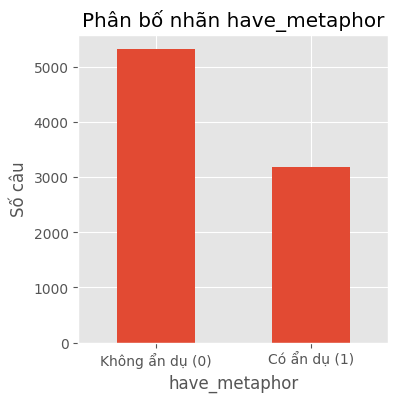

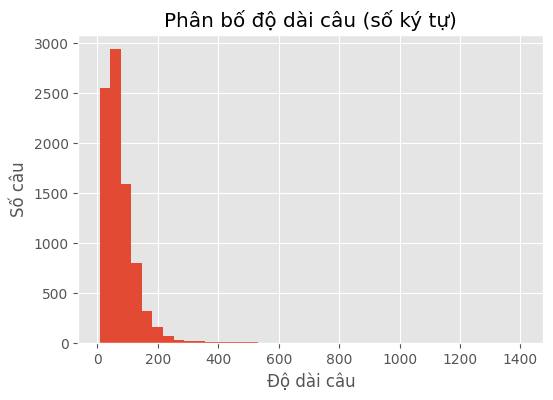

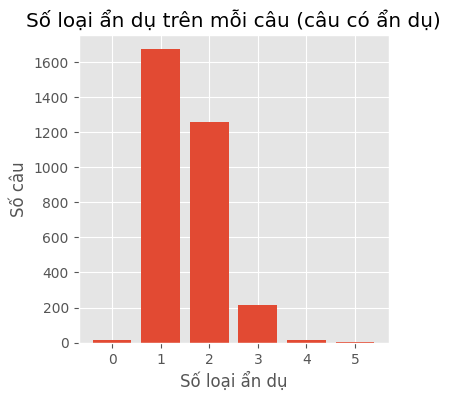

In [23]:
# Vẽ đẹp hơn một chút
plt.style.use("ggplot")

# 1) Biểu đồ cột tỉ lệ câu có / không có ẩn dụ
fig, ax = plt.subplots(figsize=(4,4))
df["have_metaphor"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xticklabels(["Không ẩn dụ (0)", "Có ẩn dụ (1)"], rotation=0)
ax.set_title("Phân bố nhãn have_metaphor")
ax.set_ylabel("Số câu")
plt.show()

# 2) Histogram độ dài câu
fig, ax = plt.subplots(figsize=(6,4))
df["sentence_len"].hist(bins=40, ax=ax)
ax.set_title("Phân bố độ dài câu (số ký tự)")
ax.set_xlabel("Độ dài câu")
ax.set_ylabel("Số câu")
plt.show()

# 3) Histogram số loại ẩn dụ (chỉ trên câu có ẩn dụ)
fig, ax = plt.subplots(figsize=(4,4))
df[df["have_metaphor"] == 1]["num_metaphor_types"].hist(bins=[0,1,2,3,4,5,6], ax=ax, align="left", rwidth=0.8)
ax.set_xticks(range(0,6))
ax.set_title("Số loại ẩn dụ trên mỗi câu (câu có ẩn dụ)")
ax.set_xlabel("Số loại ẩn dụ")
ax.set_ylabel("Số câu")
plt.show()

In [24]:
# Lấy keys trong scores từ 1 mẫu có scores
sample_scores = df["scores"].dropna().iloc[0]
print("Keys trong scores:", sample_scores.keys())

score_keys = list(sample_scores.keys())

# Tạo cột score_<key>
for k in score_keys:
    col_name = f"score_{k}"
    df[col_name] = np.nan

def copy_scores(row):
    s = row["scores"]
    if isinstance(s, dict):
        for k in score_keys:
            col = f"score_{k}"
            row[col] = s.get(k, np.nan)
    return row

df = df.apply(copy_scores, axis=1)

df[[c for c in df.columns if c.startswith("score_")]].head()

Keys trong scores: dict_keys(['accuracy', 'clarity', 'naturalness', 'meaning', 'modality', 'implication', 'syntax', 'context', 'overall', 'quality'])


,score_accuracy,score_clarity,score_naturalness,score_meaning,score_modality,score_implication,score_syntax,score_context,score_overall,score_quality
0,4.0,4.0,4.0,3.0,3.0,4.0,2.0,3.0,3.15,4.0
1,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,3.90,4.0
2,3.0,3.0,3.0,2.0,3.0,2.0,1.0,2.0,2.15,3.0
3,4.0,4.0,4.0,3.0,3.0,3.0,2.0,3.0,2.90,4.0
4,4.0,4.0,4.0,3.0,3.0,3.0,2.0,3.0,2.90,4.0


In [25]:
# Chia train / temp (dev+test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["have_metaphor"]
)

# Chia dev / test
dev_df, test_df = train_test_split(
    temp_df,
    test_size=2/3,  # 2/3 của 30% = 20% tổng
    random_state=42,
    stratify=temp_df["have_metaphor"]
)

print("Train:", len(train_df), "Dev:", len(dev_df), "Test:", len(test_df))

Train: 5950 Dev: 850 Test: 1701


In [26]:
df["split"] = None
df.loc[train_df.index, "split"] = "train"
df.loc[dev_df.index, "split"] = "dev"
df.loc[test_df.index, "split"] = "test"

print(df["split"].value_counts())

split
train    5950
test     1701
dev       850
Name: count, dtype: int64


In [27]:
plt.style.use("ggplot")

# Đếm số mẫu mỗi split
print("Số mẫu mỗi split:")
print(df["split"].value_counts(), "\n")

# Bảng tỉ lệ 0/1 trong từng split
dist = (
    df.groupby("split")["have_metaphor"]
      .value_counts(normalize=True)
      .rename("ratio")
      .reset_index()
)
print("Tỉ lệ have_metaphor trong từng split:")
print(dist)


Số mẫu mỗi split:
split
train    5950
test     1701
dev       850
Name: count, dtype: int64 

Tỉ lệ have_metaphor trong từng split:
   split  have_metaphor     ratio
0    dev              0  0.625882
1    dev              1  0.374118
2   test              0  0.625514
3   test              1  0.374486
4  train              0  0.625714
5  train              1  0.374286


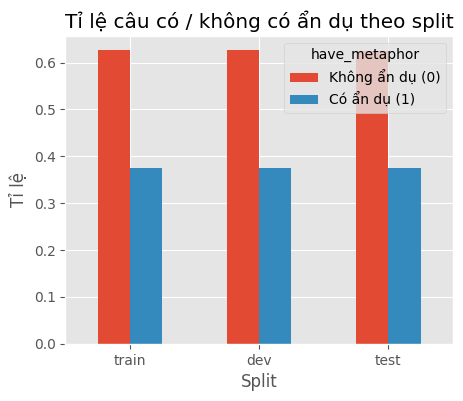

In [28]:
fig, ax = plt.subplots(figsize=(5,4))

(
    df.groupby("split")["have_metaphor"]
      .value_counts(normalize=True)
      .unstack()
      .loc[["train","dev","test"]]   # đảm bảo thứ tự
      .plot(kind="bar", ax=ax)
)

ax.set_title("Tỉ lệ câu có / không có ẩn dụ theo split")
ax.set_ylabel("Tỉ lệ")
ax.set_xlabel("Split")
ax.legend(["Không ẩn dụ (0)", "Có ẩn dụ (1)"], title="have_metaphor")
plt.xticks(rotation=0)
plt.show()

In [32]:
def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or x is None:
        return []
    return x

df["metaphor_types"] = df["metaphor_types"].apply(ensure_list)

In [33]:
# Lấy danh sách tất cả type xuất hiện
all_types = sorted({t for lst in df["metaphor_types"] for t in lst})
print("Các loại ẩn dụ tìm được:", all_types)

Các loại ẩn dụ tìm được: ['cultural_folklore', 'emotional', 'ontological', 'orientational', 'other', 'structural']


In [34]:
splits = ["train", "dev", "test"]

# DataFrame: index = loại ẩn dụ, columns = split, value = số lần xuất hiện
type_counts = pd.DataFrame(index=all_types, columns=splits).fillna(0)

for split in splits:
    sub = df[(df["split"] == split) & (df["have_metaphor"] == 1)]
    c = Counter()
    for types in sub["metaphor_types"]:
        c.update(types)
    for t, cnt in c.items():
        type_counts.loc[t, split] = cnt

print("Số lần xuất hiện từng loại ẩn dụ (chỉ trên câu có ẩn dụ):")
display(type_counts)

Số lần xuất hiện từng loại ẩn dụ (chỉ trên câu có ẩn dụ):


/tmp/ipykernel_48/1902301501.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  type_counts = pd.DataFrame(index=all_types, columns=splits).fillna(0)


,train,dev,test
cultural_folklore,261,39,81
emotional,1217,164,349
ontological,1070,162,326
orientational,198,30,60
other,17,1,5
structural,645,97,190


In [35]:
type_ratios = type_counts.div(type_counts.sum(axis=0), axis=1)
print("Tỉ lệ từng loại ẩn dụ trong mỗi split:")
display(type_ratios)

Tỉ lệ từng loại ẩn dụ trong mỗi split:


,train,dev,test
cultural_folklore,0.076585,0.079108,0.080119
emotional,0.357101,0.332657,0.345203
ontological,0.313967,0.328600,0.322453
orientational,0.058099,0.060852,0.059347
other,0.004988,0.002028,0.004946
structural,0.189261,0.196755,0.187933


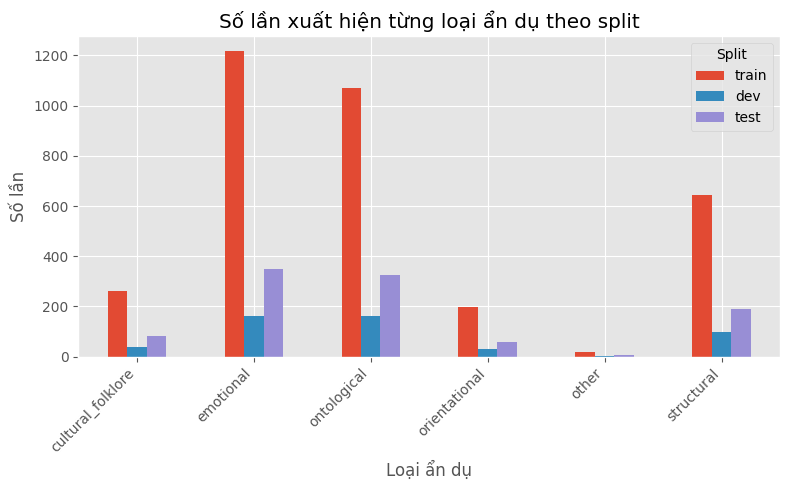

In [36]:
fig, ax = plt.subplots(figsize=(8,5))

type_counts.plot(kind="bar", ax=ax)
ax.set_title("Số lần xuất hiện từng loại ẩn dụ theo split")
ax.set_xlabel("Loại ẩn dụ")
ax.set_ylabel("Số lần")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

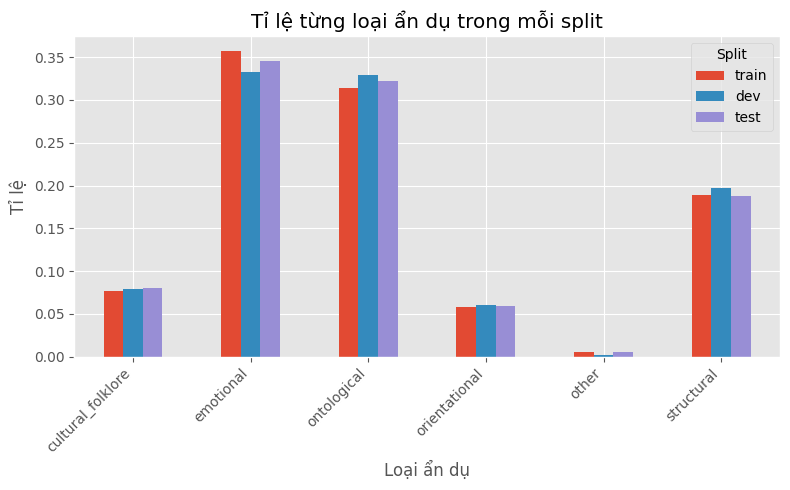

In [37]:
fig, ax = plt.subplots(figsize=(8,5))

type_ratios.plot(kind="bar", ax=ax)
ax.set_title("Tỉ lệ từng loại ẩn dụ trong mỗi split")
ax.set_xlabel("Loại ẩn dụ")
ax.set_ylabel("Tỉ lệ")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

In [38]:
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_out = os.path.join(OUTPUT_DIR, "vimunch_train.csv")
dev_out   = os.path.join(OUTPUT_DIR, "vimunch_dev.csv")
test_out  = os.path.join(OUTPUT_DIR, "vimunch_test.csv")
all_out   = os.path.join(OUTPUT_DIR, "vimunch_all_with_split.csv")

train_df.to_csv(train_out, index=False)
dev_df.to_csv(dev_out, index=False)
test_df.to_csv(test_out, index=False)
df.to_csv(all_out, index=False)

print("Đã lưu:")
print(train_out)
print(dev_out)
print(test_out)
print(all_out)

Đã lưu:
/kaggle/working/vimunch_train.csv
/kaggle/working/vimunch_dev.csv
/kaggle/working/vimunch_test.csv
/kaggle/working/vimunch_all_with_split.csv
